# Around the Discrete Fourier Transform

The Fourier transform is a mathematical tool widely used in many fields of application to analyze the frequency decomposition of a function or signal (commonly referred to as the signal spectrum). 

The presence of peaks in the spectrum makes it possible to detect the presence of harmonic components and, more generally, to determine whether the signal fluctuation is slow (low-frequency spectrum) or fast (high-frequency spectrum).


The  <b> Fourier transform</b> $\hat{f}(x)$ of a function $f(t)$  is defined as follows 
$$ \hat{f}(x)=\int_{-\infty}^{+\infty} f(t) e^{-i2\pi x t} dt.$$
Its existence is conditioned by the convergence of this integral.

In signal processing, the expression of the function $f(t)$ that we wish to analyze is unknown. We have observations of a physical quantity $f(t)$ at regular intervals  $\Delta t = 1/f_e$ ($f_e$ is called the <b>sampling frequency</b>) over a finite observation period $T=N f_e$: we refer to this as a signal, a sequence of $N$ values denoted $f[k]$ with $k\in [0, N-1]$. 

We will see that it is still possible to numerically evaluate the Fourier transform of signal $f$ by discretizing the Fourier integral with a step size $\Delta t$ (sampling) and limiting it to the observation time $T$ (window function). This is referred to as the <b>Discrete Fourier Transform</b> (DFT).   

The objectives of this tutorial are to:

- understand how to evaluate and analyze the DFT of a signal,

- understand the main effects of sampling and windowing on the DFT,  

- know how to choose a sampling frequency and windowing suitable for a given context.



<u><b>... Some practical examples of how TFD can be used:</u></b> 

<u>Vibration analysis of rotating machinery:</u> 

Defects in rotating machines generate harmonic vibrations whose frequencies enable them to be identified.

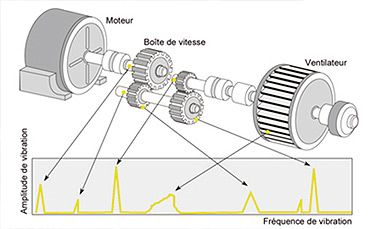

<u>Structural modal analysis:</u>


The spectrum of a structure's vibrational response to an impact allows its natural frequencies to be identified.

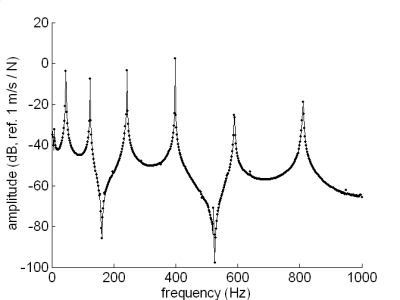

<u>Analysis of tidal cycles:</u> 

The spectrum of water level changes allows us to analyze and forecast tides.

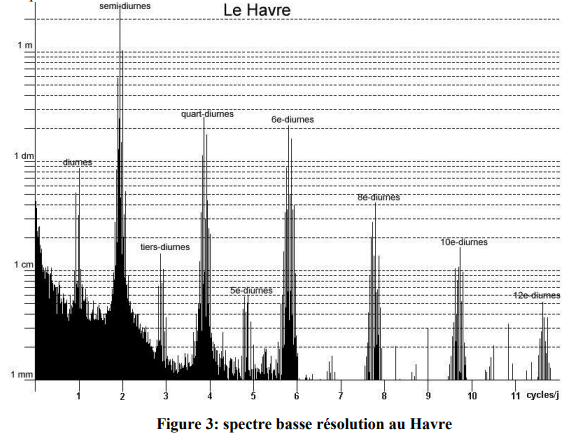



**Preliminary work**

Let $\hat{f}(x)$ the Fourier transform of  $f(t)$ :
$$ \hat{f}(x)=\int_{-\infty}^{+\infty} f(t) e^{-i2\pi x t} dt$$
We consider the continuous periodic function $\hat{g}(x)$ defined as follows
$$ \hat{g}(x) = \sum_{m \in \Z} \hat{f}(x-m a) = \sum_{m \in \Z} \int_{-\infty}^{+\infty} f(t) e^{-i2\pi x t}e^{-m a t} $$





We want to calculate the Fourier series decomposition of $\hat{g}(x)$ :
$$ S_{\hat{g}}(x) = \sum_{k \in \Z} C_k e^{i2\pi x k/a}  \textnormal{\ \ with \ \ } C_k=\frac{1}{a} \int_{-a/2}^{a/2} \hat{g}(x) e^{-i2\pi x k/a} dx$$
We show that we can also write
$$ C_k= \frac{1}{a} \int_{-a/2}^{a/2} \sum_{m \in \Z} \hat{f}(x-m a) e^{-i2\pi x k/a} dx =

\frac{1}{a} \int_{-\infty}^{+\infty} \hat{f}(x) e^{-i2\pi x k/a} dx= \frac{1}{a} f(-k/a)$$



and consequently
$$ \hat{g}(x) =S_{\hat{g}}(x) = \frac{1}{a} \sum_{k \in \Z} f(k/a) e^{-i2\pi x k/a} \approx \int_{-\infty}^{+\infty} f(t) e^{-i2\pi x t} dt$$
where we recognize on the right a discretized version for the Fourier integral of $f(t)$ with $t=k/a$ and $dt=1/a$. 

The function $\hat{g}(x)$ is called the Discrete Fourier Transform of $f(t)$. 

Under what conditions can we verify  $\hat{g}(x)=\hat{f}(x) \forall x \in [-a/2 ; a/2]$?


Compliance with this condition, also known as Shannon's criterion, ensures that it is possible to numerically estimate the FT of a function $f(t)$ on the interval $x \in [-a/2; a/2]$ based solely on the knowledge of the values taken by $f(t)$ at the abscissas $k/a$.

***
**Numerical implementation**

We now consider a discrete signal $s[k]$ associated with the abscissas $t[k]$, regularly spaced by $\Delta t$.

The discrete Fourier transform consists of numerically evaluating the Fourier integral from the values  $s[k]$ of the known signal at times  $t[k]$:
$$
\hat{s}(x)=\int_{-\infty}^{+\infty} s(t) e^{-i2\pi x t} dt   \ \ \ \Rightarrow  \ \ \  \hat{s}_d(x)=   \Delta t  \sum_{k} s[k] e^{-i 2 \pi x t[k]} $$

Complete the function tfd(s,t,x) below, which evaluates the discrete transform of the signal s at frequencies $x$, such that $s[k]=s(t[k])$.

Use this function to evaluate the DFT of a cosine signal.

In [ ]:
import numpy as np
pi=np.pi
import matplotlib.pyplot as plt
# %matplotlib widget



# DFT
def tfd(s,t,x):
  out = np.zeros((len(x), 1),dtype=np.complex128)
  for i in range(len(x)):
    out[i] = np.sum(s * np.exp(-1j*2*pi*x[i]*t))
  return out


# signal parameters (duration T, sampling freq fe, frequency f0 )
T=.1
fe=1000
f0=100*2**.5

# sampling the analytic signal
t=np.arange(0,T,1/fe)
s=np.cos(2*pi*f0*t)

# choose frequency resolution and interval for DFT calculation
dx=1/2/T
x=np.arange(-2*fe,2*fe,dx)

# DFT calculation
S=tfd(s,t,x)/fe


fig, ax = plt.subplots(1, 2, figsize=(12,5))   
ax[0].plot(t,s,'-k')
ax[0].set_xlabel('t')
ax[0].set_title('Time signal')
ax[0].grid()
ax[1].plot(x,np.abs(S),'-k', label=r'$\|\hat{s}(x)\|$');
ax[1].set_xlabel('x')
ax[1].grid()
ax[1].set_title('Discrete Fourier Transform (amplitude)')



ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

**Using the FFT (Fast Fourier Transform)**

The Fast Fourier Transform is a famous algorithm popularized in the 1965 by Cooley and Tukey, used to efficiently compute the DFT. The fft is available in numpy, use it below to compute the DFT, verify that it gives same results as the naive function written above, and measure the computation time of both. 

tfd took  0.013478200000008655 s
fft took  0.0003372000001036213 s


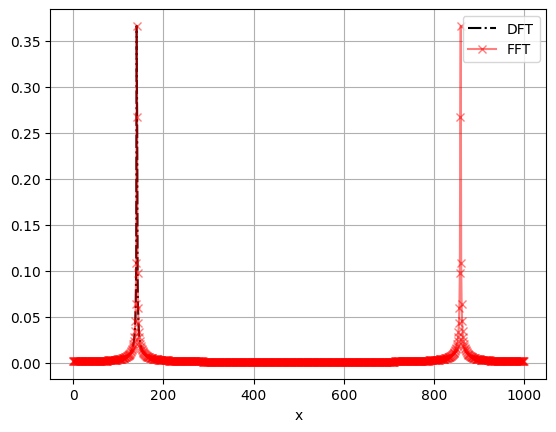

In [10]:
import time


# signal parameters (duration T, sampling freq fe, frequency f0 )
T=1
fe=1000
f0=100*2**.5

# sampling the analytic signal
t=np.arange(0,T,1/fe)
s=np.cos(2*pi*f0*t)


# choose frequency resolution and interval for DFT calculation
dx=1/T
x=np.arange(0,fe/2,dx)

# DFT calculation
start = time.perf_counter()
S=tfd(s,t,x)/fe
end = time.perf_counter()

print('tfd took ',end-start, 's' )

# fft calculation
start = time.perf_counter()
Sfft=np.fft.fft(s)/fe
end = time.perf_counter()
print('fft took ',end-start, 's' )


xfft=np.arange(0,len(s))/len(s)*fe
plt.figure()
plt.plot(x,np.abs(S),'-.k', label=r'DFT')
plt.plot(xfft,np.abs(Sfft),'-xr', label='FFT',alpha=0.5)
plt.xlabel('x')
plt.grid()
plt.legend()



**Using weighting windows**

The numerical implementation of the DFT requires in practice to use finite length signals. Truncating the DFT sum is equivalent to calculating the DFT of the signal multiplied by an observation window, with a rectangular shape:


$$
\Delta t  \sum_{k=0}^{N-1} s[k] e^{-i 2 \pi x t[k]} = \Delta t  \sum_{k=-\infty}^{\infty} s[k] w[k] e^{-i 2 \pi x t[k]} = TFD\{s(t)w(t)\} $$

where 
$$ w(t)=1 \ \ \forall t \in [0, (N-1) \Delta t] \ \  , \ \ w(t)=0 \ \textnormal{elsewhere} $$

As a consequence, the spectrum resulting from the TFD is the convolution between the true spectrum and the Fourier transform of the window. This explains why the DFT of the cosine is not a pure Dirac but is spread over few frequency bins, following a cardinal sine distribution. The spreading width is approximately equal to the inverse of the window's length, defining the frequency resolution $1/T=N/f_e$ of the Fourier analysis.

In practice, it can be interesting to weight the observation window with a shape that is smoother than a Boxcar (uniform) in order to attenuate sidelobes of the cardinal sine.

A classical weighting used in signal processing is the hanning window, whose expression is based on a cosine function

$$ w[k]=\frac{1}{2} \left( 1-\cos\left(\frac{2\pi k}{N-1} \right) \right)$$

Complete the code below to to apply the hanning weighting. Adjust the correction factor so that the amplitude of the peak is the same as the uniform weighting. 


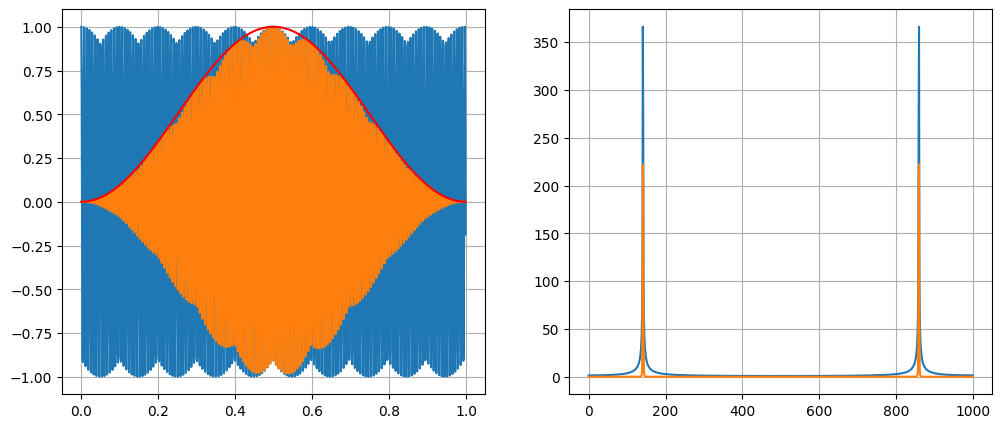

In [12]:


# fenetrage
corrfact=0.5

win=( 1-np.cos((2*np.pi*t*fe) / (fe*T-1)) )*corrfact

fig, ax = plt.subplots(1, 2, figsize=(12,5)) 
ax[0].plot(t,s)
ax[0].plot(t,s*win)
ax[0].plot(t,win, 'r')

ax[0].grid()

ax[1].plot(xfft,np.abs(np.fft.fft(s)))
ax[1].plot(xfft,np.abs(np.fft.fft(s*win)))
ax[1].grid()



**Square signal synthesis**

A square wave is a periodic signal that can be decomposed into a series of sines using Fourier series decomposition. Assuming an odd square function, it can be decomposed into sines :

$$q(t)=S_{q}(t) = \sum_k B_k \sin(2\pi k f_0 t)$$
where
$$ B_k=4 f_0 \int_{0}^{1/2f_0} \sin(2\pi f_0 t k) dt = \frac{2}{k\pi} (1-(-1)^k)$$



We want to generate a discrete square wave signal with a period of $1/f_0$, with a discretization step of $dt=1/1000$, for a duration of 1s.

Design and implement a code below that can simply generate this signal, consisting of values equal to 1 or -1.

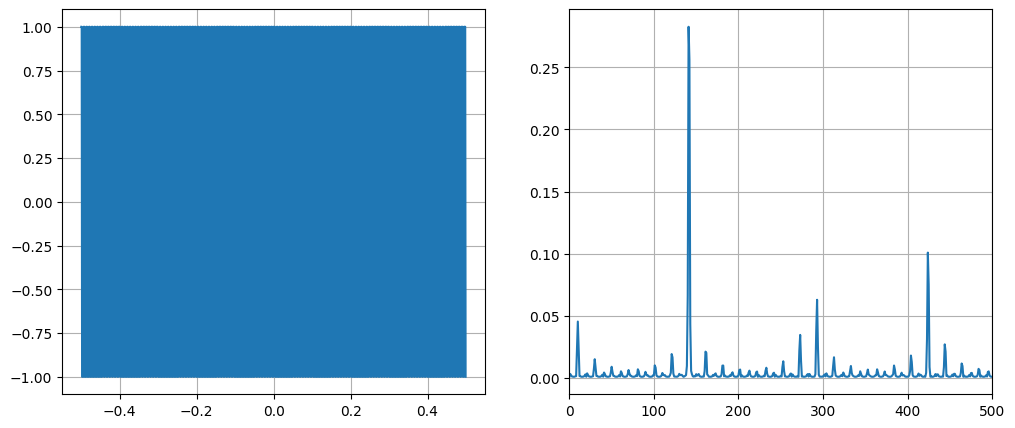

In [16]:

def square(t,f0):
  return np.sign(np.sin(2 * np.pi * f0 * t))

T=1/2
f0=100*2**.5
fe=1000
t=np.arange(-T,T,1/fe)
q=square(t,f0)


Qw=np.fft.fft(q*np.hanning(len(q)))/fe
x=np.arange(0,len(Qw))/len(Qw)*fe

fig, ax = plt.subplots(1, 2, figsize=(12,5)) 
ax[0].plot(t,q)
ax[0].grid()

ax[1].plot(x,np.abs(Qw))
ax[1].set_xlim((0,fe/2))
ax[1].grid()



Does the TF seem to correspond to what is expected based on the Fourier series decomposition? What is the name of the phenomenon observed?

Now complete the code below to generate the square wave signal from its Fourier series decomposition. Take particular care to respect Shannon's criterion.

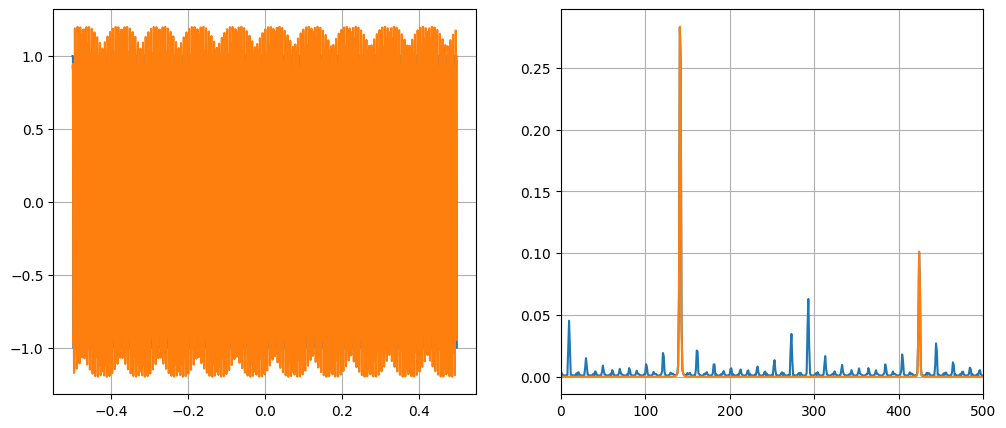

In [17]:

def square2(t,f0,fe):
  fe=1/(t[1]-t[0])
  out=t*0
  k=1
  while k*f0<fe/2:
    out=out+4/(k*pi)*np.sin(2*pi*k*f0*t)
    k=k+2
  return out


q2=square2(t,f0,fe)

Q2w=np.fft.fft(q2*np.hanning(len(q2)))/fe

fig, ax = plt.subplots(1, 2, figsize=(12,5)) 
ax[0].plot(t,q)
ax[0].plot(t,q2)
ax[0].grid()

ax[1].plot(x,np.abs(Qw))
ax[1].plot(x,np.abs(Q2w))
ax[1].set_xlim((0,fe/2))
ax[1].grid()

**Beyond Shannon's limit using Irregular sampling** 

In some applications, the number of sampling points $N$ can be sometimes limited by practical considerations. If we want to respect the Shannon's rule, with respect to an expected frequency content with $f_{max}$, it leads to a limited aperture $T=N/(2f_{max})$, which limits the frequency resolution. It is still possible to inscrease $T$, but we know that aliasing will potentially appear, and it will be not possible to identify the true harmonic components from aliased ones.  Irregular sampling can be a solution is such situations if we are interested in identifying the true frequency of a harmonic component.

We will sample below a signal made of two harmonic components, with $N=500$ points. We want to perform a Harmonic analysis on a frequency range limited by $f_{max}=50kHz.$

Build the time vector and calculate and plot the DFT of the signal between 0 and $f_{max}$ :

- respecting the Shannon's criterion (regular sampling)

- with a frequency resolution power of $10Hz$ (aperture of $.1s$) (regular sampling)

- an irregular sampling on an aperture of $.1s$

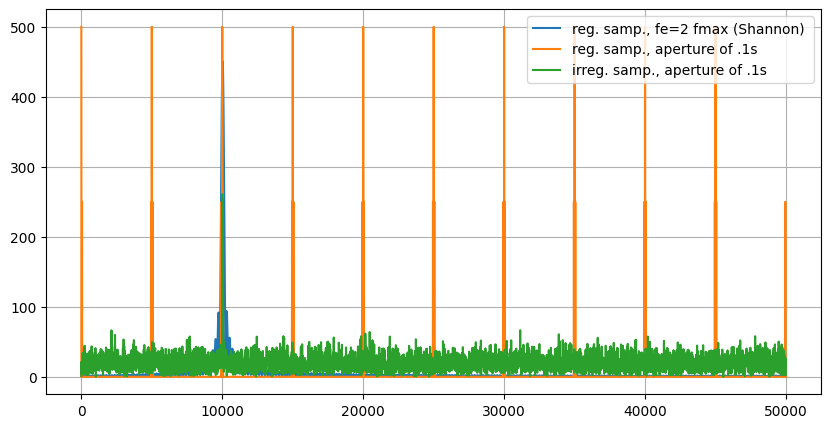

In [ ]:
def sig(t,f0,f1):
    return np.cos(2*pi*f0*t)+np.cos(2*pi*f1*t)


f0=10000
f1=10050
N=500

# frequency analysis parameters
fmax=50000
df=10
x=np.arange(0,fmax,df)


# Regular sampling respecting Shannon
fe=2*fmax
t1=np.arange(0,N)/fe

# Regular sampling with T=0.1 (deltaf=10Hz)
fe=N/0.1
t2=np.arange(0,N)/fe

# irregular sampling T=0.1 (resolution freq 10Hz)
t3=np.random.rand(N)*0.1

plt.figure(figsize=(10,5))
plt.plot(x,np.abs(tfd(sig(t1,f0,f1),t1,x)),label='reg. samp., fe=2 fmax (Shannon) ')
plt.plot(x,np.abs(tfd(sig(t2,f0,f1),t2,x)),label='reg. samp., aperture of .1s')
plt.plot(x,np.abs(tfd(sig(t3,f0,f1),t3,x)),label='irreg. samp., aperture of .1s')
plt.legend()
plt.grid()


